# Hotel Booking Cancellation Prediction

Machine learning assessment using the Hotel Booking Demand dataset.

**Objective:** Predict whether a hotel booking will be cancelled using Logistic Regression, Decision Tree, Random Forest, and SVM, followed by Random Forest hyperparameter tuning with GridSearchCV.

## 1. Import Libraries

In [1]:
import os
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')


## 2. Load Dataset

In [2]:
DATA_PATH = 'hotel_bookings.csv'
df = pd.read_csv(DATA_PATH)

print(f'Dataset shape: {df.shape}')
display(df.head())

Dataset shape: (119390, 32)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


## 3. Initial Inspection

In [3]:
print('Data types and non-null counts:')
df.info()

print('\nDescriptive statistics:')
display(df.describe(include='all').T)

Data types and non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-nul

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
hotel,119390,2,City Hotel,79330,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_canceled,119390.0,NaN,NaN,NaN,0.370416,0.482918,0.0,0.0,0.0,1.0,1.0
lead_time,119390.0,NaN,NaN,NaN,104.011416,106.863097,0.0,18.0,69.0,160.0,737.0
arrival_date_year,119390.0,NaN,NaN,NaN,2016.156554,0.707476,2015.0,2016.0,2016.0,2017.0,2017.0
arrival_date_month,119390,12,August,13877,NaN,NaN,NaN,NaN,NaN,NaN,NaN
arrival_date_week_number,119390.0,NaN,NaN,NaN,27.165173,13.605138,1.0,16.0,28.0,38.0,53.0
arrival_date_day_of_month,119390.0,NaN,NaN,NaN,15.798241,8.780829,1.0,8.0,16.0,23.0,31.0
stays_in_weekend_nights,119390.0,NaN,NaN,NaN,0.927599,0.998613,0.0,0.0,1.0,2.0,19.0
stays_in_week_nights,119390.0,NaN,NaN,NaN,2.500302,1.908286,0.0,1.0,2.0,3.0,50.0
adults,119390.0,NaN,NaN,NaN,1.856403,0.579261,0.0,2.0,2.0,2.0,55.0


## 4. Missing Values and Duplicates

In [4]:
missing = df.isnull().sum().sort_values(ascending=False)
display(missing[missing > 0].to_frame('Missing Values'))

print('Duplicate rows:', df.duplicated().sum())

,Missing Values
company,112593
agent,16340
country,488
children,4


Duplicate rows: 31994


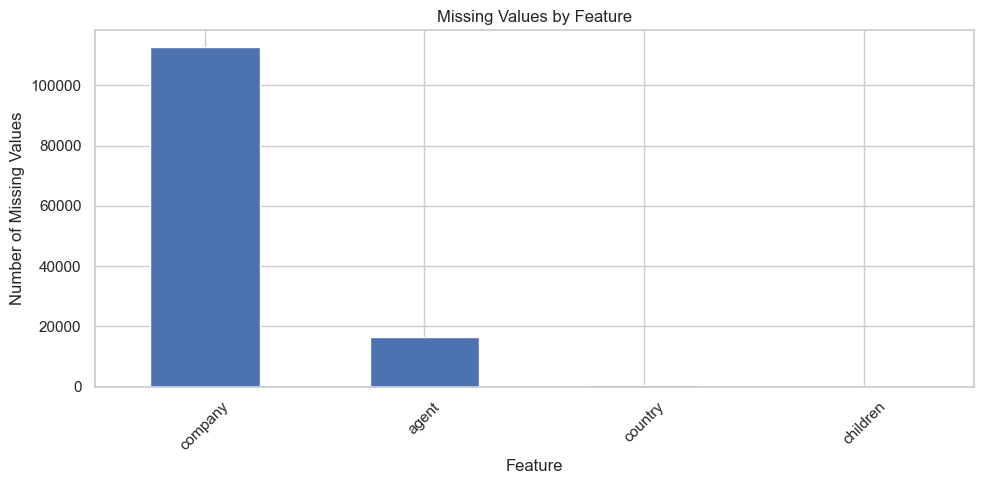

In [5]:
plt.figure(figsize=(10, 5))
missing[missing > 0].plot(kind='bar')
plt.title('Missing Values by Feature')
plt.xlabel('Feature')
plt.ylabel('Number of Missing Values')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5. Data Cleaning

In [6]:
# Remove exact duplicate records.
df = df.drop_duplicates().copy()

# Handle known missing values.
df['children'] = df['children'].fillna(0)
df['country'] = df['country'].fillna('Unknown')
df['agent'] = df['agent'].fillna(0)
df['company'] = df['company'].fillna(0)

# Remove records with zero adults because they are not meaningful bookings for this task.
df = df[df['adults'] > 0].copy()

print('Shape after cleaning:', df.shape)
print('Remaining missing values:', int(df.isnull().sum().sum()))

Shape after cleaning: (87011, 32)
Remaining missing values: 0


## 6. Target Variable Analysis

is_canceled
0    63083
1    23928
Name: count, dtype: int64

Percentage distribution:


is_canceled
0    72.5
1    27.5
Name: proportion, dtype: float64

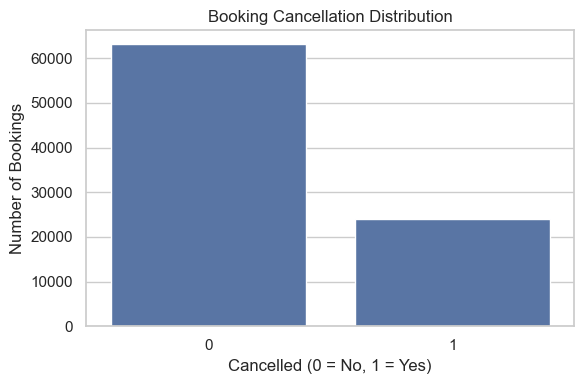

In [7]:
print(df['is_canceled'].value_counts())
        

print('\nPercentage distribution:')
display((df['is_canceled'].value_counts(normalize=True) * 100).round(2))

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='is_canceled')
plt.title('Booking Cancellation Distribution')
plt.xlabel('Cancelled (0 = No, 1 = Yes)')
plt.ylabel('Number of Bookings')
plt.tight_layout()
plt.show()

## 7. Exploratory Data Analysis

### Cancellation by Hotel Type

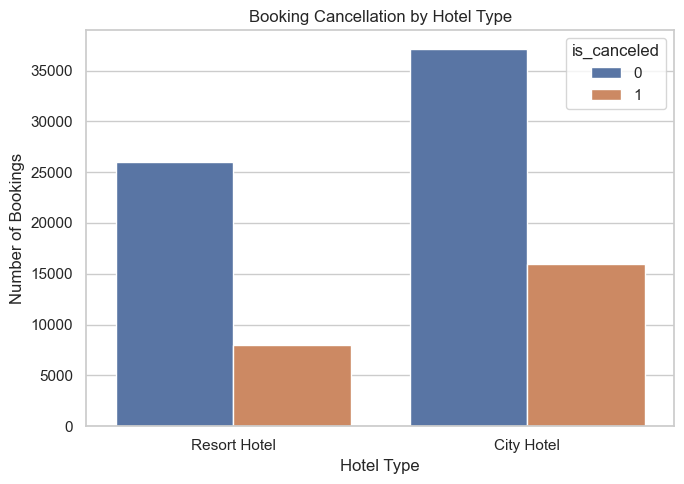

In [8]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='hotel', hue='is_canceled')
plt.title('Booking Cancellation by Hotel Type')
plt.xlabel('Hotel Type')
plt.ylabel('Number of Bookings')
plt.tight_layout()
plt.show()


### Lead Time vs Cancellation

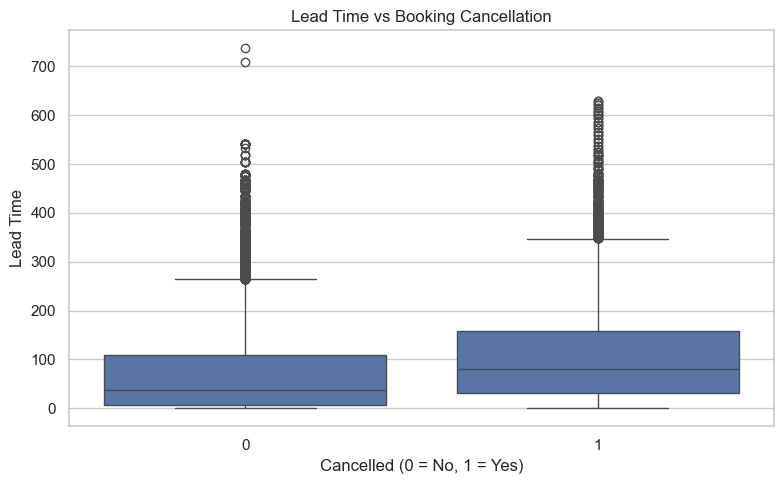

In [9]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='is_canceled', y='lead_time')
plt.title('Lead Time vs Booking Cancellation')
plt.xlabel('Cancelled (0 = No, 1 = Yes)')
plt.ylabel('Lead Time')
plt.tight_layout()
plt.show()


### Cancellation by Market Segment

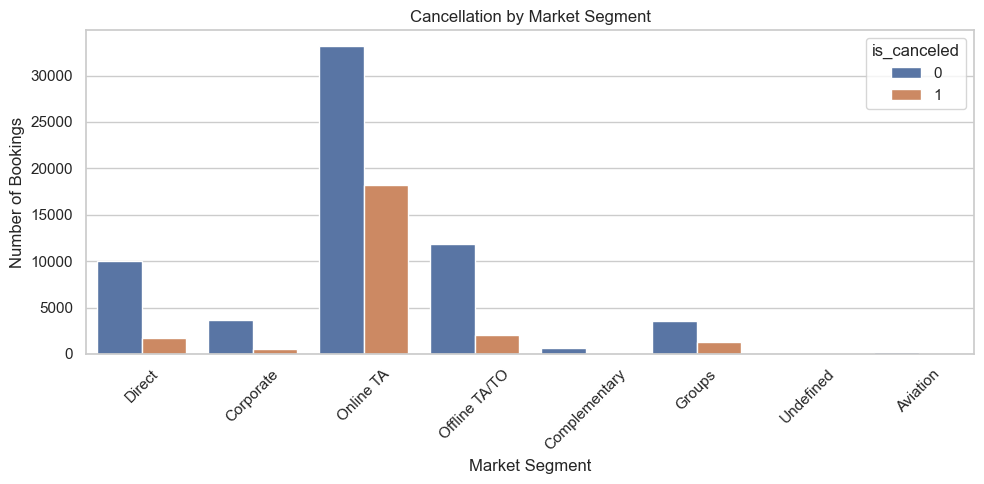

In [10]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='market_segment', hue='is_canceled')
plt.title('Cancellation by Market Segment')
plt.xlabel('Market Segment')
plt.ylabel('Number of Bookings')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Cancellation by Deposit Type

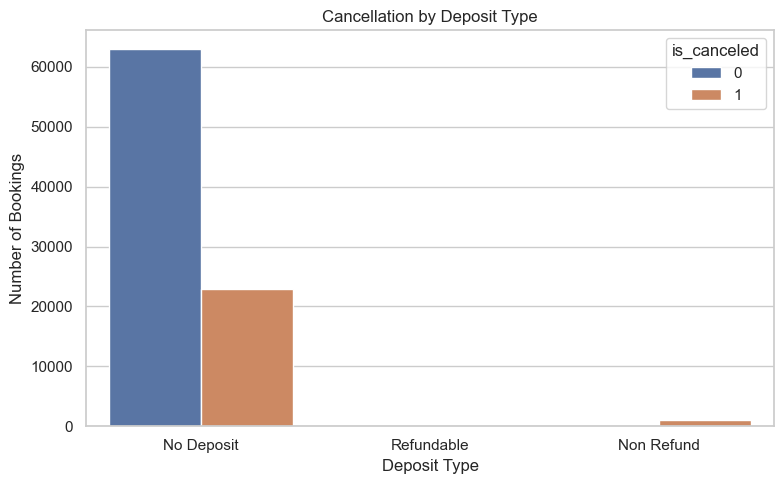

In [11]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='deposit_type', hue='is_canceled')
plt.title('Cancellation by Deposit Type')
plt.xlabel('Deposit Type')
plt.ylabel('Number of Bookings')
plt.tight_layout()
plt.show()


### Cancellation by Customer Type

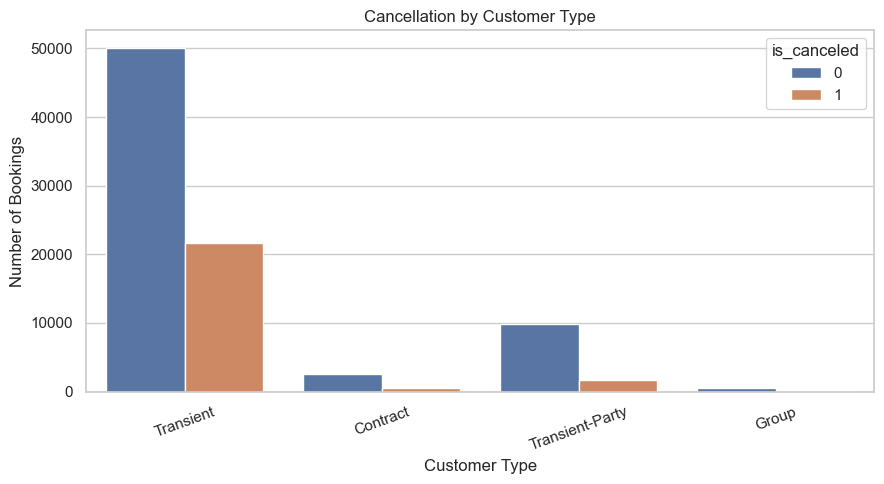

In [12]:
plt.figure(figsize=(9, 5))
sns.countplot(data=df, x='customer_type', hue='is_canceled')
plt.title('Cancellation by Customer Type')
plt.xlabel('Customer Type')
plt.ylabel('Number of Bookings')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


### Numerical Correlation

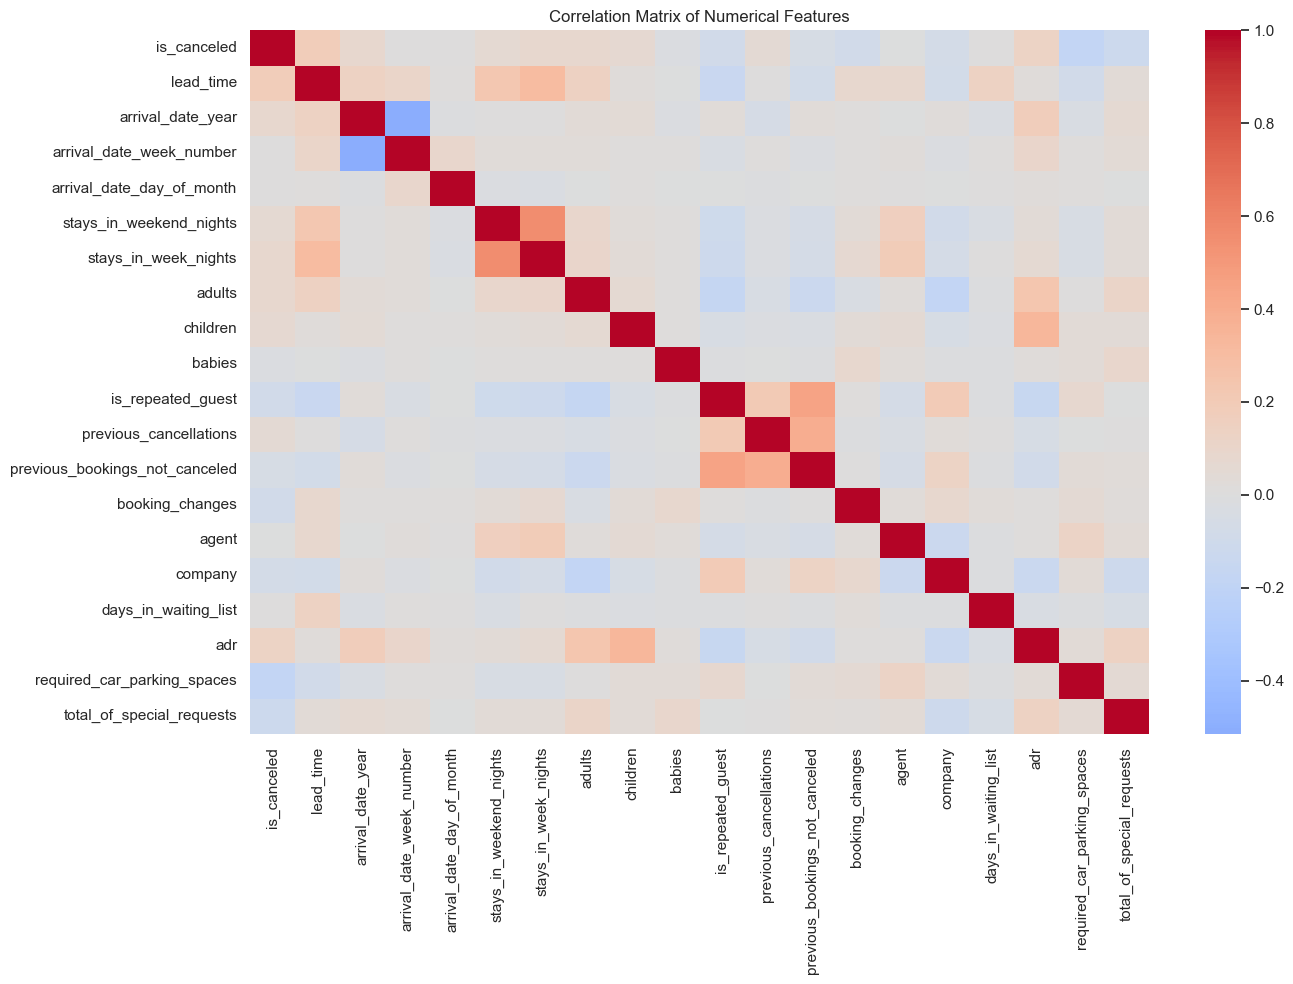

In [13]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(14, 10))
sns.heatmap(numeric_df.corr(), cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Numerical Features')
plt.tight_layout()
plt.show()

## 8. Feature Engineering

In [14]:
df['total_guests'] = df['adults'] + df['children'] + df['babies']
df['total_nights'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']
df['total_stay_cost'] = df['adr'] * df['total_nights']

display(df[['total_guests', 'total_nights', 'total_stay_cost']].head())

,total_guests,total_nights,total_stay_cost
0,2.0,0,0.0
1,2.0,0,0.0
2,1.0,1,75.0
3,1.0,1,75.0
4,2.0,2,196.0


## 9. Remove Data Leakage and Unnecessary Identifier Columns

`reservation_status` and `reservation_status_date` are excluded because they describe the reservation outcome and would leak information from after the booking decision. Agent and company IDs are also excluded from the predictive feature set.

In [15]:
df_model = df.drop(
    columns=['reservation_status', 'reservation_status_date', 'agent', 'company']
).copy()

print('Modeling dataset shape:', df_model.shape)

Modeling dataset shape: (87011, 31)


## 10. Features and Target

In [16]:
X = df_model.drop(columns='is_canceled')
y = df_model['is_canceled']

categorical_features = X.select_dtypes(include=['object']).columns.tolist()
numerical_features = X.select_dtypes(exclude=['object']).columns.tolist()

print('Categorical features:', categorical_features)
print('\nNumerical features:', numerical_features)

Categorical features: ['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type']

Numerical features: ['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'total_guests', 'total_nights', 'total_stay_cost']


## 11. Train/Test Split

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print('Training set:', X_train.shape)
print('Testing set:', X_test.shape)

Training set: (69608, 30)
Testing set: (17403, 30)


## 12. Preprocessing Pipeline

In [18]:
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numerical_features),
    ('cat', categorical_transformer, categorical_features)
])

## 13. Train Four Classification Models

In [19]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "SVM": LinearSVC(
    random_state=42,
    max_iter=2000
)
}

trained_models = {}
results = []

for name, model in models.items():
    print(f'Training {name}...')

    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred)
    })

    trained_models[name] = pipeline

results_df = pd.DataFrame(results)
display(results_df.style.format({
    'Accuracy': '{:.4f}',
    'Precision': '{:.4f}',
    'Recall': '{:.4f}',
    'F1 Score': '{:.4f}'
}))

Training Logistic Regression...
Training Decision Tree...
Training Random Forest...
Training SVM...


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.7955,0.6806,0.4831,0.5651
1,Decision Tree,0.7929,0.6223,0.6283,0.6253
2,Random Forest,0.8393,0.7728,0.5890,0.6685
3,SVM,0.7937,0.6868,0.4590,0.5503


## 14. Classification Reports

In [20]:
for name, model in trained_models.items():
    print('=' * 70)
    print(name)
    print('=' * 70)
    print(classification_report(y_test, model.predict(X_test)))

Logistic Regression
              precision    recall  f1-score   support

           0       0.82      0.91      0.87     12617
           1       0.68      0.48      0.57      4786

    accuracy                           0.80     17403
   macro avg       0.75      0.70      0.72     17403
weighted avg       0.78      0.80      0.78     17403

Decision Tree
              precision    recall  f1-score   support

           0       0.86      0.86      0.86     12617
           1       0.62      0.63      0.63      4786

    accuracy                           0.79     17403
   macro avg       0.74      0.74      0.74     17403
weighted avg       0.79      0.79      0.79     17403

Random Forest
              precision    recall  f1-score   support

           0       0.86      0.93      0.89     12617
           1       0.77      0.59      0.67      4786

    accuracy                           0.84     17403
   macro avg       0.81      0.76      0.78     17403
weighted avg       0.83   

## 15. Confusion Matrices

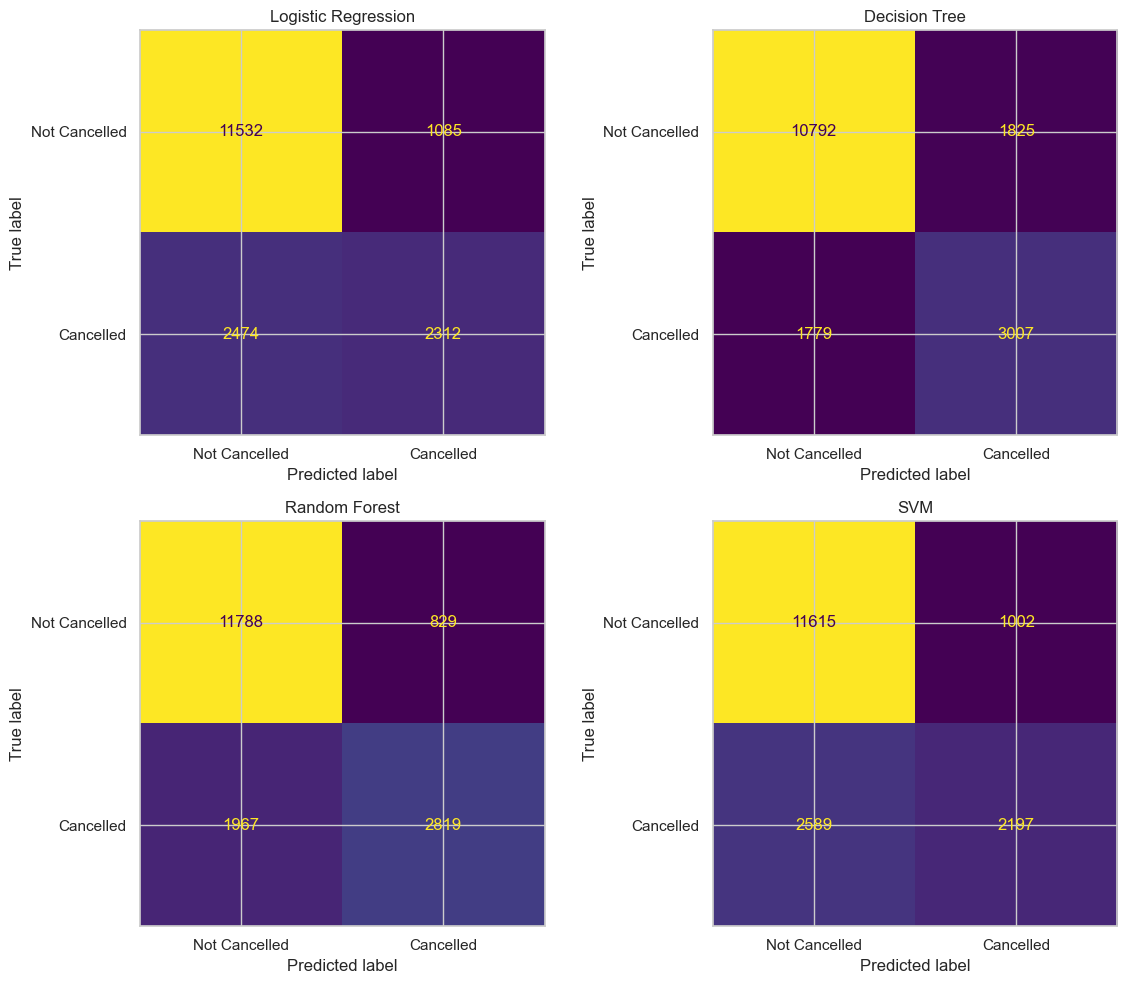

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, (name, model) in zip(axes.ravel(), trained_models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Not Cancelled', 'Cancelled']
    ).plot(ax=ax, values_format='d', colorbar=False)
    ax.set_title(name)

plt.tight_layout()
plt.show()

## 16. Model Performance Comparison

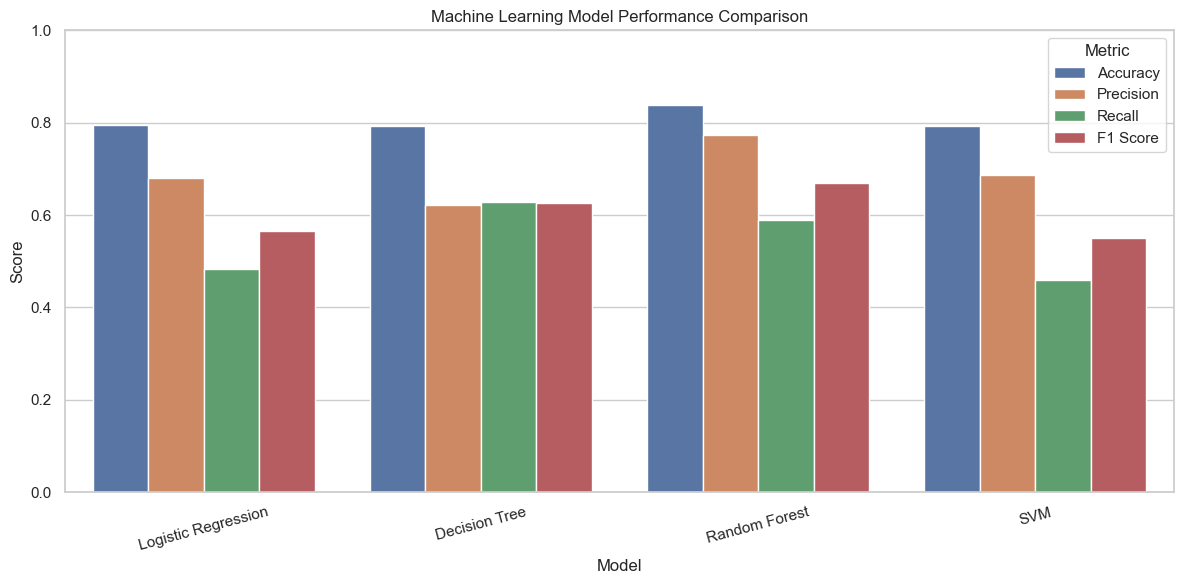

In [22]:
plot_df = results_df.melt(
    id_vars='Model',
    value_vars=['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    var_name='Metric',
    value_name='Score'
)

plt.figure(figsize=(12, 6))
sns.barplot(data=plot_df, x='Model', y='Score', hue='Metric')
plt.title('Machine Learning Model Performance Comparison')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 17. Hyperparameter Tuning with GridSearchCV

In [23]:
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(random_state=42, n_jobs=-1))
])

param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf': [1, 2]
}

grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print('Best parameters:')
print(grid_search.best_params_)
print('\nBest cross-validation F1:', grid_search.best_score_)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best parameters:
{'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 200}

Best cross-validation F1: 0.6743507095575678


## 18. Evaluate Tuned Random Forest

In [24]:
best_rf = grid_search.best_estimator_
y_pred_tuned = best_rf.predict(X_test)

tuned_results = {
    'Model': 'Tuned Random Forest',
    'Accuracy': accuracy_score(y_test, y_pred_tuned),
    'Precision': precision_score(y_test, y_pred_tuned),
    'Recall': recall_score(y_test, y_pred_tuned),
    'F1 Score': f1_score(y_test, y_pred_tuned)
}

display(pd.DataFrame([tuned_results]))

print(classification_report(y_test, y_pred_tuned))

,Model,Accuracy,Precision,Recall,F1 Score
0,Tuned Random Forest,0.840143,0.770811,0.595905,0.672166


              precision    recall  f1-score   support

           0       0.86      0.93      0.89     12617
           1       0.77      0.60      0.67      4786

    accuracy                           0.84     17403
   macro avg       0.81      0.76      0.78     17403
weighted avg       0.83      0.84      0.83     17403



## 19. Original vs Tuned Random Forest

In [25]:
original_rf = results_df[results_df['Model'] == 'Random Forest'].iloc[0]

comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Original Random Forest': [
        original_rf['Accuracy'], original_rf['Precision'],
        original_rf['Recall'], original_rf['F1 Score']
    ],
    'Tuned Random Forest': [
        tuned_results['Accuracy'], tuned_results['Precision'],
        tuned_results['Recall'], tuned_results['F1 Score']
    ]
})

display(comparison.style.format({
    'Original Random Forest': '{:.4f}',
    'Tuned Random Forest': '{:.4f}'
}))

,Metric,Original Random Forest,Tuned Random Forest
0,Accuracy,0.8393,0.8401
1,Precision,0.7728,0.7708
2,Recall,0.5890,0.5959
3,F1 Score,0.6685,0.6722


## 20. Feature Importance

,Feature,Importance
0,num__lead_time,0.110873
19,num__total_stay_cost,0.072963
14,num__adr,0.072675
3,num__arrival_date_day_of_month,0.058408
16,num__total_of_special_requests,0.054437
2,num__arrival_date_week_number,0.052803
165,cat__country_PRT,0.040808
18,num__total_nights,0.033432
5,num__stays_in_week_nights,0.031792
213,cat__market_segment_Online TA,0.025404


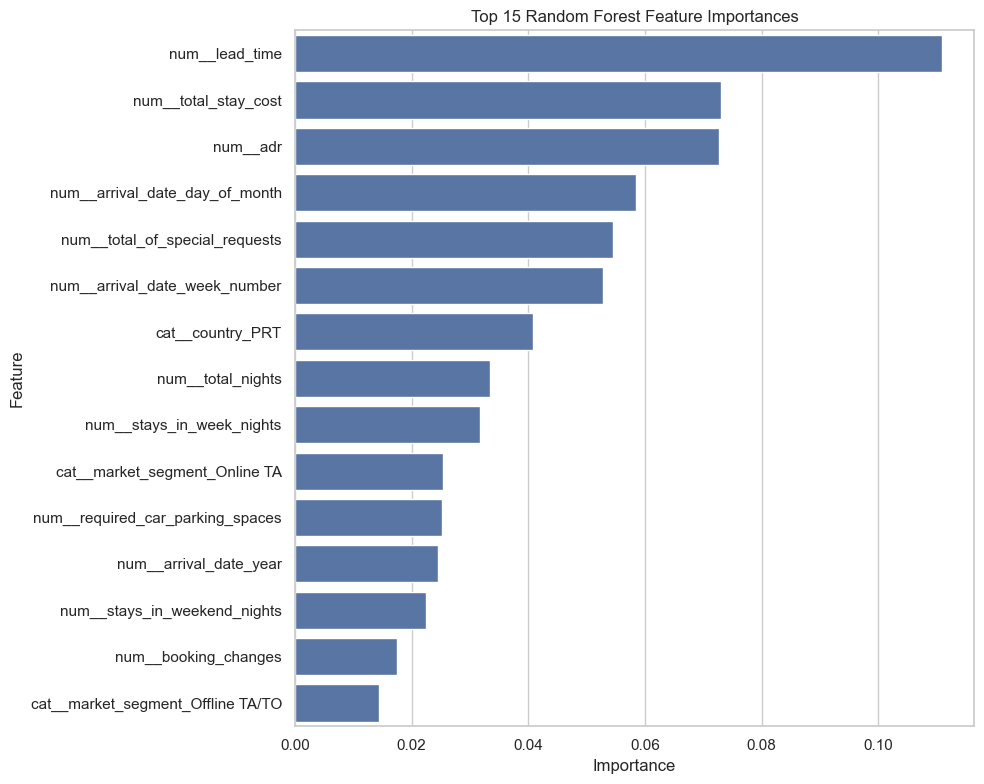

In [26]:
feature_names = best_rf.named_steps['preprocessor'].get_feature_names_out()
importances = best_rf.named_steps['model'].feature_importances_

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

display(feature_importance.head(20))

plt.figure(figsize=(10, 8))
sns.barplot(data=feature_importance.head(15), x='Importance', y='Feature')
plt.title('Top 15 Random Forest Feature Importances')
plt.tight_layout()
plt.show()

## 21. Final Model Comparison

In [27]:
final_results = pd.concat([
    results_df,
    pd.DataFrame([tuned_results])
], ignore_index=True)

display(final_results.style.format({
    'Accuracy': '{:.4f}',
    'Precision': '{:.4f}',
    'Recall': '{:.4f}',
    'F1 Score': '{:.4f}'
}))

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.7955,0.6806,0.4831,0.5651
1,Decision Tree,0.7929,0.6223,0.6283,0.6253
2,Random Forest,0.8393,0.7728,0.5890,0.6685
3,SVM,0.7937,0.6868,0.4590,0.5503
4,Tuned Random Forest,0.8401,0.7708,0.5959,0.6722


## 22. Save Trained Models

In [28]:
os.makedirs('models', exist_ok=True)

for name, model in trained_models.items():
    filename = name.lower().replace(' ', '_') + '.pkl'
    joblib.dump(model, os.path.join('models', filename))

joblib.dump(best_rf, 'models/tuned_random_forest.pkl')

print('All models saved successfully in the models/ directory.')

All models saved successfully in the models/ directory.


## Conclusion

The notebook compared four classification algorithms for hotel booking cancellation prediction. Model performance was evaluated using accuracy, precision, recall, and F1-score. Random Forest was additionally optimized using GridSearchCV, and feature importance was analyzed to understand the main predictive variables.